## Crime Data Preprocessing Notebook

## Overview
This notebook loads, inspects and cleans UK crime data across 4 police forces 
Metropolitan, West Yorkshire, Devon & Cornwall, North Yorkshire covering 2024-01 to 2025-08.

The cleaned data will be saved as CSV files for use in the analysis notebook.

## Contents
1. Street Data - Loading, Inspection & Cleaning
2. Stop & Search Data - Loading, Inspection & Cleaning
3. ONS Population Data - Merge & Export

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

SECTION 1 Loading one CSV file first to inspect the structure, understand the columns 
and identify any data quality issues before doing the same for the full dataset.

In [29]:
#Loading a single file to inspect
df = pd.read_csv('2024-01/2024-01-metropolitan-street.csv')
df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,e5b3ed0375b796067eb668f37a18094cce300bdbd5446c...,2024-01,Metropolitan Police Service,Metropolitan Police Service,-0.552328,50.853155,On or near Queen Street,E01031392,Arun 001C,Other theft,Unable to prosecute suspect,NaN
1,d5d46efe4a74b2fdf87f28f7c89c4d7534c80d4150f58f...,2024-01,Metropolitan Police Service,Metropolitan Police Service,-0.666558,50.848940,On or near Northfields Lane,E01031396,Arun 003D,Violence and sexual offences,Status update unavailable,NaN
2,8ee491f5ebeda54bda879fed602d2f308bfd8abf4b59f7...,2024-01,Metropolitan Police Service,Metropolitan Police Service,-0.657460,50.787270,On or near Kingsmead,E01031419,Arun 015C,Violence and sexual offences,Status update unavailable,NaN
3,318e91d9bd9ad081bb348b8c743236365c9178eb60229d...,2024-01,Metropolitan Police Service,Metropolitan Police Service,0.876815,51.147655,On or near Parking Area,E01034986,Ashford 005G,Violence and sexual offences,Status update unavailable,NaN
4,8ec949bf76f02215ad73b489ff502ab32101b0834b49fc...,2024-01,Metropolitan Police Service,Metropolitan Police Service,0.884060,51.110654,On or near Southdown Close,E01034989,Ashford 010G,Violence and sexual offences,Status update unavailable,NaN


In [30]:
df.shape

(91411, 12)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 91411 entries, 0 to 91410
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crime ID               74897 non-null  str    
 1   Month                  91411 non-null  str    
 2   Reported by            91411 non-null  str    
 3   Falls within           91411 non-null  str    
 4   Longitude              90739 non-null  float64
 5   Latitude               90739 non-null  float64
 6   Location               91411 non-null  str    
 7   LSOA code              90739 non-null  str    
 8   LSOA name              90739 non-null  str    
 9   Crime type             91411 non-null  str    
 10  Last outcome category  74897 non-null  str    
 11  Context                0 non-null      float64
dtypes: float64(3), str(9)
memory usage: 8.4 MB


In [32]:
df.tail()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
91406,8ddefd590ca561e28874692b8ec02db292d208439336a4...,2024-01,Metropolitan Police Service,Metropolitan Police Service,NaN,NaN,No Location,NaN,NaN,Other crime,Court result unavailable,NaN
91407,acd9c90a29c22c3e4a53f1765662e4d718cb397af451c1...,2024-01,Metropolitan Police Service,Metropolitan Police Service,NaN,NaN,No Location,NaN,NaN,Other crime,Court result unavailable,NaN
91408,0a978c195f0daadccaf473f131f50f663f4340618ea802...,2024-01,Metropolitan Police Service,Metropolitan Police Service,NaN,NaN,No Location,NaN,NaN,Other crime,Unable to prosecute suspect,NaN
91409,827178f4c74110dc649c5ac8136653139a58c10f78090d...,2024-01,Metropolitan Police Service,Metropolitan Police Service,NaN,NaN,No Location,NaN,NaN,Other crime,Investigation complete; no suspect identified,NaN
91410,b92bceced18cc53c5fcb377f0b154e7b69b96b484c7648...,2024-01,Metropolitan Police Service,Metropolitan Police Service,NaN,NaN,No Location,NaN,NaN,Other crime,Local resolution,NaN


In [33]:
df.isnull().sum()

Crime ID                 16514
Month                        0
Reported by                  0
Falls within                 0
Longitude                  672
Latitude                   672
Location                     0
LSOA code                  672
LSOA name                  672
Crime type                   0
Last outcome category    16514
Context                  91411
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(8024)

In [35]:
df.describe()

,Longitude,Latitude,Context
count,90739.000000,90739.000000,0.0
mean,-0.121020,51.511942,NaN
std,0.157308,0.081372,NaN
min,-4.219770,50.701061,NaN
25%,-0.196748,51.473003,NaN
50%,-0.118025,51.514829,NaN
75%,-0.033954,51.552337,NaN
max,1.411904,54.966167,NaN


##Checking the main collumns which need to be analysed to understand the different crime types, police forces and time periods.

In [36]:
# Distribution of crime types
df["Crime type"].value_counts()

Crime type
Violence and sexual offences    21679
Anti-social behaviour           16514
Other theft                     10297
Vehicle crime                    8970
Theft from the person            6915
Burglary                         5082
Shoplifting                      5053
Criminal damage and arson        4874
Public order                     4159
Robbery                          2946
Drugs                            2713
Bicycle theft                     969
Other crime                       831
Possession of weapons             409
Name: count, dtype: int64

In [37]:
# Police forces in the dataset
df["Falls within"].value_counts()

Falls within
Metropolitan Police Service    91411
Name: count, dtype: int64

In [38]:
# Check if 'Reported by' and 'Falls within' are the same as they can be merged to create one column name. 
print((df['Reported by'] == df['Falls within']).all())

True


In [39]:
# Months covered
df["Month"].value_counts()

Month
2024-01    91411
Name: count, dtype: int64

In [40]:
# Check LSOA code and LSOA name columns
print(df['LSOA code'].value_counts().head())
print(df['LSOA name'].value_counts().head())

LSOA code
E01035716    1509
E01004763    1148
E01004734    1024
E01004736     532
E01002444     474
Name: count, dtype: int64
LSOA name
Westminster 013G    1509
Westminster 013B    1148
Westminster 018A    1024
Westminster 018C     532
Hillingdon 031A      474
Name: count, dtype: int64


Based on the previous information cleaning decsions were made. These being:

Collumn data was going to be removed as no analysis can be done with it as its empty. 
Drop rows were longitude and latitude are null as they cannot be used for mapping.
Delete any duplicated rows.
Convert the month to a valid datetime as its currently stored as String (seen in df.info)
'Reported by' and 'Falls within' were confirmed to be identical columns so decided to merge them into one single column 'Police Force'.
LSOA code contains reference numbers which cant be used for no analysis so were dropped. LSOA name was renamed to 'Area' for clarity.

In [41]:
# Keep original safe, work on a copy
df_clean = df.copy()

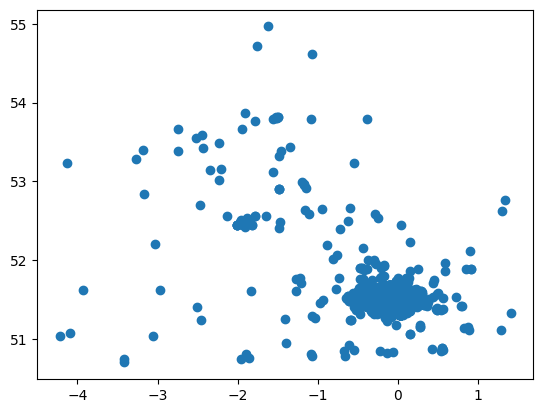

In [42]:
#Scatter plot to see all points are linked to graph.
plt.scatter(df_clean['Longitude'], df_clean['Latitude'])
plt.show()

In [43]:
# Drop Context column - 100% empty
df_clean.drop(columns=['Context'], inplace=True)
# Drop rows with missing location data
df_clean.dropna(subset=['Longitude', 'Latitude'], inplace=True)
# Drop duplicate rows
df_clean.drop_duplicates(inplace=True)
# Convert Month to datetime
df_clean['Month'] = pd.to_datetime(df_clean['Month'])

In [44]:
# Fill missing Crime IDs - anti-social behaviour crimes have no ID
df_clean['Crime ID'] = df_clean['Crime ID'].fillna('No Crime ID')
# Fill missing outcomes - anti-social behaviour crimes have no outcome
df_clean['Last outcome category'] = df_clean['Last outcome category'].fillna('No Outcome')
# Merge identical columns into single Police Force column
df_clean['Police Force'] = df_clean['Falls within']
df_clean.drop(columns=['Reported by', 'Falls within'], inplace=True)
# Drop LSOA code and rename LSOA name to Area
df_clean.drop(columns=['LSOA code'], inplace=True)
df_clean.rename(columns={'LSOA name': 'Area'}, inplace=True)

In [45]:
print(df_clean.isnull().sum())
print(df_clean.shape)

Crime ID                 0
Month                    0
Longitude                0
Latitude                 0
Location                 0
Area                     0
Crime type               0
Last outcome category    0
Police Force             0
dtype: int64
(82723, 9)


The cleaning process has been cleaned on one file, we can use the GLOB library to clean all the street CSV files. 

In [46]:
# Load all street CSVs across all forces and months
all_files = glob.glob('**/*-street.csv', recursive=True)
print(f"Total files found: {len(all_files)}")

Total files found: 96


In [47]:
# Combine all files into one dataframe
df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
df.shape

(3313260, 12)

In [48]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3313260 entries, 0 to 3313259
Data columns (total 12 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Crime ID               str    
 1   Month                  str    
 2   Reported by            str    
 3   Falls within           str    
 4   Longitude              float64
 5   Latitude               float64
 6   Location               str    
 7   LSOA code              str    
 8   LSOA name              str    
 9   Crime type             str    
 10  Last outcome category  str    
 11  Context                float64
dtypes: float64(3), str(9)
memory usage: 303.3 MB


np.int64(251718)

In [49]:
df_clean = df.copy()

In [50]:
# Check if 'Reported by' and 'Falls within' are identical across all forces
print((df['Reported by'] == df['Falls within']).all())

True


In [51]:
#Copy the exact same cleaning methods as we did with the single file. 
df_clean.drop(columns=['Context'], inplace=True)
df_clean.dropna(subset=['Longitude', 'Latitude'], inplace=True)
df_clean.drop_duplicates(inplace=True)
df_clean['Month'] = pd.to_datetime(df_clean['Month'])
df_clean['Crime ID'] = df_clean['Crime ID'].fillna('No Crime ID')
df_clean['Last outcome category'] = df_clean['Last outcome category'].fillna('No Outcome')
df_clean['Police Force'] = df_clean['Falls within']
df_clean.drop(columns=['Reported by', 'Falls within'], inplace=True)
df_clean.drop(columns=['LSOA code'], inplace=True)
df_clean.rename(columns={'LSOA name': 'Area'}, inplace=True)


In [52]:
print(df_clean.isnull().sum())

Crime ID                 0
Month                    0
Longitude                0
Latitude                 0
Location                 0
Area                     8
Crime type               0
Last outcome category    0
Police Force             0
dtype: int64


When loading all the CSV files, 8 rows were found with null Area values despite having valid longitude and latitude coordinates. These rows were filled with 'Unknown' as it is better data cleaning rather than leaving them empty.

In [53]:
# Replacing empty Area values with Unknown
df_clean['Area'] = df_clean['Area'].fillna('Unknown')
#Confirm all columns produce 0's.
print(df_clean.isnull().sum())

Crime ID                 0
Month                    0
Longitude                0
Latitude                 0
Location                 0
Area                     0
Crime type               0
Last outcome category    0
Police Force             0
dtype: int64


In [54]:
df_clean.isnull().sum()
df_clean.shape

(3039777, 9)

In [55]:
# Save clean street data
df_clean.to_csv('clean_street.csv', index=False)
print("Street data saved successfully!")

Street data saved successfully!


In [56]:
# Test clean street data loaded correctly
test = pd.read_csv('clean_street.csv')
test.shape

(3039777, 9)

Ran a test to see if all the coordinates are between the 4 police forces which will be used for analysis. 

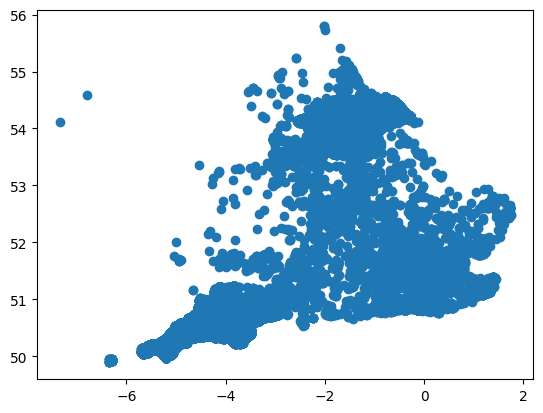

In [57]:
plt.scatter(test['Longitude'], test['Latitude'])
plt.show()

Two points appeared outside the main cluster with Longitude below -5. 
These were investigated and found to belong to Devon & Cornwall Police, specifically Cornwall and the Isles of Scilly. 

In [58]:
test[test['Longitude'] < -5]

,Crime ID,Month,Longitude,Latitude,Location,Area,Crime type,Last outcome category,Police Force
319,5a3ea0d25a221343ad4fb03190a6fa47855ee0570fee87...,2024-01-01,-5.022266,50.527021,On or near Parking Area,Cornwall 008B,Drugs,Unable to prosecute suspect,Devon & Cornwall Police
702,47db5f76bfb521e1474809f331e4f89f5ad6fc7399227c...,2024-01-01,-5.049263,50.428985,On or near Trevelgue Road,Cornwall 018A,Public order,Unable to prosecute suspect,Devon & Cornwall Police
703,7f3d9e481bfd07cb039fed76c554e50fd5ba473cdd2943...,2024-01-01,-5.063776,50.421704,On or near Lusty Glaze Road,Cornwall 018A,Violence and sexual offences,Status update unavailable,Devon & Cornwall Police
704,a1b56a4e1b4d7e8959b2874c6e772bbdf51db6a36e0665...,2024-01-01,-5.054441,50.426079,On or near Alexandra Road,Cornwall 018A,Violence and sexual offences,Status update unavailable,Devon & Cornwall Police
705,054732db91d7618606ccf3e60f58faeca7fae450ecc45c...,2024-01-01,-5.023420,50.402656,On or near Quintrell Gardens,Cornwall 018C,Public order,Unable to prosecute suspect,Devon & Cornwall Police
...,...,...,...,...,...,...,...,...,...
2924649,08f8fc728aeabccb450e5614e96e6eec36bb29d6450bfa...,2025-12-01,-6.316902,49.915135,On or near Supermarket,Isles of Scilly 001A,Violence and sexual offences,Unable to prosecute suspect,Devon & Cornwall Police
2924650,3e2cd33a55b7a1336fe5084cabaa48ab76f9e339f375c3...,2025-12-01,-6.302189,49.919705,On or near Rocky Hill Lane,Isles of Scilly 001A,Violence and sexual offences,Under investigation,Devon & Cornwall Police
2924651,f6ea014f34a53af91e393d95af3b5ba29bf50874c42f5a...,2025-12-01,-6.316902,49.915135,On or near Supermarket,Isles of Scilly 001A,Violence and sexual offences,Under investigation,Devon & Cornwall Police
2924652,663a20761e69899ab8df258aa6f7daaa5152917bdbc552...,2025-12-01,-6.308739,49.913919,On or near A3112,Isles of Scilly 001A,Violence and sexual offences,Unable to prosecute suspect,Devon & Cornwall Police


Running final validation checks on the clean dataset to confirm the data is ready for analysis.

In [59]:
test['Crime type'].value_counts()
print(f"Total unique crime types: {test['Crime type'].nunique()}")

Total unique crime types: 14


In [60]:
print(test['Month'].value_counts().sort_index())
print(f"\nTotal months: {test['Month'].nunique()}")

Month
2024-01-01    120391
2024-02-01    118236
2024-03-01    124465
2024-04-01    122670
2024-05-01    130899
2024-06-01    129624
2024-07-01    134412
2024-08-01    131001
2024-09-01    125613
2024-10-01    133254
2024-11-01    129318
2024-12-01    121479
2025-01-01    117271
2025-02-01    112770
2025-03-01    126527
2025-04-01    125584
2025-05-01    133085
2025-06-01    133484
2025-07-01    140221
2025-08-01    131077
2025-09-01    125049
2025-10-01    129469
2025-11-01    124036
2025-12-01    119842
Name: count, dtype: int64

Total months: 24


In [61]:
print(test['Police Force'].value_counts())
print(f"\nTotal forces: {test['Police Force'].nunique()}")

Police Force
Metropolitan Police Service    2062333
West Yorkshire Police           591387
Devon & Cornwall Police         272161
North Yorkshire Police          113896
Name: count, dtype: int64

Total forces: 4


Section 3: Loading the ONS population estimates for 2024 for further analysis. 

In [62]:
#Loading the population data
ons = pd.read_csv('police_population_2024.csv')
ons.head()

,PFA 2023 Code,Police_Force,Population_2024,Year,F0,F1,F2,F3,F4,F5,...,M76,M77,M78,M79,M80,M81,M82,M83,M84,M85
0,E23000001,Metropolitan Police Service,"9,074,625",2024,51526,51041,52918,50777,51276,50664,...,21814,22697,17361,15658,15144,13481,11793,10164,10433,55460
1,E23000009,North Yorkshire Police,"844,571",2024,3028,3248,3582,3581,3877,3827,...,4885,5211,3800,3620,3484,2977,2547,2033,2085,10803
2,E23000010,West Yorkshire Police,"2,435,236",2024,12811,12889,13583,13364,14302,14504,...,9263,9832,6949,6532,6284,5665,4543,3920,3846,19888
3,E23000035,Devon & Cornwall Police,"1,840,161",2024,6714,7031,7527,7821,8193,8577,...,10898,12006,9009,8384,7986,7100,5789,4832,4625,24273


In [63]:
#Keeping only relevant columns for analysis
ons_clean = ons[['Police_Force', 'Population_2024']]
ons_clean

,Police_Force,Population_2024
0,Metropolitan Police Service,"9,074,625"
1,North Yorkshire Police,"844,571"
2,West Yorkshire Police,"2,435,236"
3,Devon & Cornwall Police,"1,840,161"


In [64]:
# Convert Population_2024 from string to integer
ons_clean['Population_2024'] = ons_clean['Population_2024'].str.replace(',', '').astype(int)

In [65]:
#Combine population data with crime data
ons_clean = ons_clean.rename(columns={'Police_Force': 'Police Force'})
df_final = df_clean.merge(ons_clean, on='Police Force')
df_final.shape

(3039777, 10)

In [66]:
#Test to see if population data was added to the final dataframe.
df_final.head()

,Crime ID,Month,Longitude,Latitude,Location,Area,Crime type,Last outcome category,Police Force,Population_2024
0,48c1007edc34d286b599720b7518058e9f75e6928ca2dc...,2024-01-01,-1.961000,50.745104,On or near Calder Road,"Bournemouth, Christchurch and Poole 016E",Other theft,Unable to prosecute suspect,Devon & Cornwall Police,1840161
1,4d913f4f5875e7b7726bb10f1633fdc5d3a47edd16ea5d...,2024-01-01,-0.758195,51.397477,On or near Fitzroy Close,Bracknell Forest 010D,Vehicle crime,Investigation complete; no suspect identified,Devon & Cornwall Police,1840161
2,9ac9fcc7d22103973f626a69ae4c9fefd54151d5addc1e...,2024-01-01,-2.599344,51.450094,On or near Nightclub,Bristol 061C,Theft from the person,Action to be taken by another organisation,Devon & Cornwall Police,1840161
3,e3a99af51ec4babcb0680c0f027b7254d80ba8f168adbd...,2024-01-01,-1.933391,52.751848,On or near Hilltop,Cannock Chase 003B,Violence and sexual offences,Status update unavailable,Devon & Cornwall Police,1840161
4,abe881ef6ba45b35a8e1ba5b4d5de25b9140413743c286...,2024-01-01,-1.933391,52.751848,On or near Hilltop,Cannock Chase 003B,Violence and sexual offences,Status update unavailable,Devon & Cornwall Police,1840161
